# 01_data_audit.ipynb

Auditoria exploratoria (EDA) de todas las fuentes de datos disponibles en `data/`.
Objetivo: caracterizar estructura, balance, calidad y compatibilidad de cada fuente
con los cuatro vectores de ataque del proyecto.

Vectores de ataque (referencia canonical):
- sqli           : SQL Injection
- xss            : Cross-Site Scripting
- path_traversal : Path Traversal / LFI
- cmdi           : Command Injection

Fuentes auditadas (9 grupos):
1.  `Payloads.csv`
2.  `payload_full.csv`
3.  `command injection.csv`
4.  `XSS_dataset.csv/XSS_dataset.csv`
5.  `data_capec_multilabel.csv`
6.  `modsec-learn/` (legitimate + malicious JSON)
7.  `omurugur Path_Travelsal_Payload_List master Payload/` (9 archivos .txt)
8.  `owasp/` (30 dias de logs ModSecurity)
9.  `russellmitchell/` (access logs Apache + labels JSONL)

# Seccion 1: Setup

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, re
from pathlib import Path
from urllib.parse import unquote
from collections import Counter

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 60)
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path("../data")

SOURCES = {
    "csv/Payloads"           : BASE_DIR / "Payloads.csv",
    "csv/payload_full"       : BASE_DIR / "payload_full.csv",
    "csv/command_injection"  : BASE_DIR / "command injection.csv",
    "csv/XSS_dataset"        : BASE_DIR / "XSS_dataset.csv" / "XSS_dataset.csv",
    "csv/data_capec"         : BASE_DIR / "data_capec_multilabel.csv",
    "json/legitimate"        : BASE_DIR / "modsec-learn" / "legitimate_dataset.json",
    "json/malicious_sqli"    : BASE_DIR / "modsec-learn" / "malicious_dataset.json",
    "txt/pt_wordlists_dir"   : BASE_DIR / "omurugur Path_Travelsal_Payload_List master Payload",
    "log/owasp_dir"          : BASE_DIR / "owasp",
    "log/russellmitchell"    : BASE_DIR / "russellmitchell",
}

print("Inventario de fuentes:")
for name, path in SOURCES.items():
    status = "OK" if path.exists() else "NO ENCONTRADO"
    if path.is_file():
        size = f"{path.stat().st_size / (1024**2):.1f} MB"
    elif path.is_dir():
        files = list(path.rglob("*"))
        size = f"{len([f for f in files if f.is_file()])} archivos"
    else:
        size = "--"
    print(f"  {status}  {name:<35}  {size}")

Inventario de fuentes:
  OK  csv/Payloads                         18.2 MB
  OK  csv/payload_full                     1.9 MB
  OK  csv/command_injection                0.0 MB
  OK  csv/XSS_dataset                      1.6 MB
  OK  csv/data_capec                       416.2 MB
  OK  json/legitimate                      179.1 MB
  OK  json/malicious_sqli                  5.5 MB
  OK  txt/pt_wordlists_dir                 9 archivos
  OK  log/owasp_dir                        30 archivos
  OK  log/russellmitchell                  214 archivos


# Seccion 2: Payloads.csv

Dataset de URLs completas etiquetadas como Benign/Malicious.
Los samples maliciosos son exclusivamente XSS (inspeccion confirmada: `<script>alert(...)`, `<iframe>` en query strings).
Los samples benignos son fragmentos HTML/JS de paginas reales (no trafico HTTP sintetico).
Codificacion latin-1.

In [26]:
df_payloads = pd.read_csv(SOURCES["csv/Payloads"], encoding="latin-1")
df_payloads["payload_len"] = df_payloads["Payloads"].str.len()

dupes = df_payloads.duplicated().sum()
counts = df_payloads["Class"].value_counts()

print(f"Shape      : {df_payloads.shape}")
print(f"Columnas   : {list(df_payloads.columns)}")
print(f"Duplicados : {dupes:,}  ({dupes/len(df_payloads)*100:.2f}%)")
print(f"Nulos      : {df_payloads.isnull().sum().to_dict()}")
print()
print("=== Distribucion de clases ===")
print(counts)
print(f"Ratio Benign:Malicious = {counts['Benign']/counts['Malicious']:.2f}:1")
print()
print("=== Estadisticas de longitud ===")
print(df_payloads.groupby("Class")["payload_len"].describe().round(1))

Shape      : (43217, 3)
Columnas   : ['Payloads', 'Class', 'payload_len']
Duplicados : 546  (1.26%)
Nulos      : {'Payloads': 0, 'Class': 0, 'payload_len': 0}

=== Distribucion de clases ===
Class
Benign       28068
Malicious    15149
Name: count, dtype: int64
Ratio Benign:Malicious = 1.85:1

=== Estadisticas de longitud ===
             count   mean     std   min    25%    50%    75%      max
Class                                                                
Benign     28068.0  572.1  1761.2   1.0   89.0  119.0  422.0  32758.0
Malicious  15149.0  168.5   230.9  10.0  105.0  129.0  181.0  11312.0


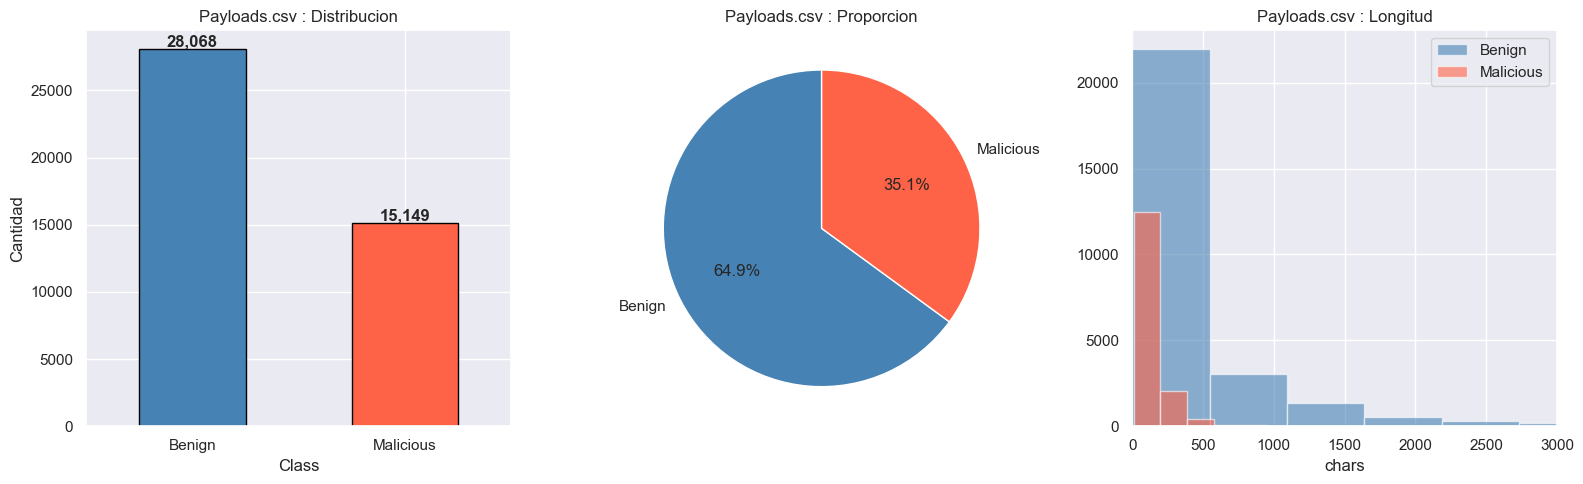


Muestras Malicious:
  'http://www.nwce.gov.uk/search_process.php?keyword=%22%3e%3cscript%3ealert%28document.cookie%29%3b%3c<br>%2fscript%3e'
  'http://www.manchester.gov.uk/site/scripts/google_results.php?q=%22%3e%253cscript%3ealert%28document.<br>cookie%29%3b%253c%2fscript'
  'http://www.ldsmissions.com/us/index.php?action=missionary.info%3cmarquee%3epappy%3c/marquee%3e&amp;missi<br>onary_id=69'


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Payloads.csv : Distribucion")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Payloads.csv : Proporcion")

for cls, color in [("Benign", "steelblue"), ("Malicious", "tomato")]:
    axes[2].hist(df_payloads[df_payloads["Class"]==cls]["payload_len"],
                 bins=60, alpha=0.6, label=cls, color=color)
axes[2].set_title("Payloads.csv : Longitud")
axes[2].set_xlabel("chars")
axes[2].set_xlim(0, 3000)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nMuestras Malicious:")
for s in df_payloads[df_payloads["Class"]=="Malicious"]["Payloads"].head(3):
    print(" ", repr(s[:130]))

## Resumen: Payloads.csv

- Filas: 43,217   |   Dupes: 546 (1.26%)   |   Nulos: 0   |   Encoding: latin-1
- Benign: 28,068 (64.9%)   |   Malicious: 15,149 (35.1%)
- Tipo de ataque: XSS exclusivamente (URLs con payloads de script/iframe en query strings)
- Columna util: `Payloads` (URL completa) -> requiere extraccion de query string
- Label: `Class` -> mapear a {xss, legitimate}

Acciones requeridas:
- Eliminar 546 duplicados
- Extraer query string de la URL (el payload de ataque esta en el parametro GET)
- Verificar que todos los Malicious son XSS (hay indicios de `<iframe>` tambien)
- Los Benign contienen HTML/JS de sitios reales: distribucion de dominio diferente a trafico HTTP de API

# Seccion 3: payload_full.csv

Dataset multi-clase con los cuatro vectores del proyecto mas trafico normal.
Payloads cortos (media 41 chars): fragmentos de parametro, no URLs completas.
La clase `norm` usa direcciones en espanol como trafico legitimo (sintetico).

In [28]:
df_full = pd.read_csv(SOURCES["csv/payload_full"], encoding="utf-8")
df_full["payload_len"] = df_full["payload"].str.len()

print(f"Shape      : {df_full.shape}")
print(f"Columnas   : {list(df_full.columns)}")
print(f"Duplicados : {df_full.duplicated().sum():,}")
print(f"Nulos      : {df_full.isnull().sum().to_dict()}")
print()
counts_at = df_full["attack_type"].value_counts()
print("=== Distribucion attack_type ===")
for k, v in counts_at.items():
    print(f"  {k:<20} : {v:>7,}  ({v/len(df_full)*100:.1f}%)")

Shape      : (31067, 5)
Columnas   : ['payload', 'length', 'attack_type', 'label', 'payload_len']
Duplicados : 0
Nulos      : {'payload': 0, 'length': 0, 'attack_type': 0, 'label': 0, 'payload_len': 0}

=== Distribucion attack_type ===
  norm                 :  19,304  (62.1%)
  sqli                 :  10,852  (34.9%)
  xss                  :     532  (1.7%)
  path-traversal       :     290  (0.9%)
  cmdi                 :      89  (0.3%)


C:\Users\thiag\AppData\Local\Temp\ipykernel_26968\51295518.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x="attack_type", y="payload_len",


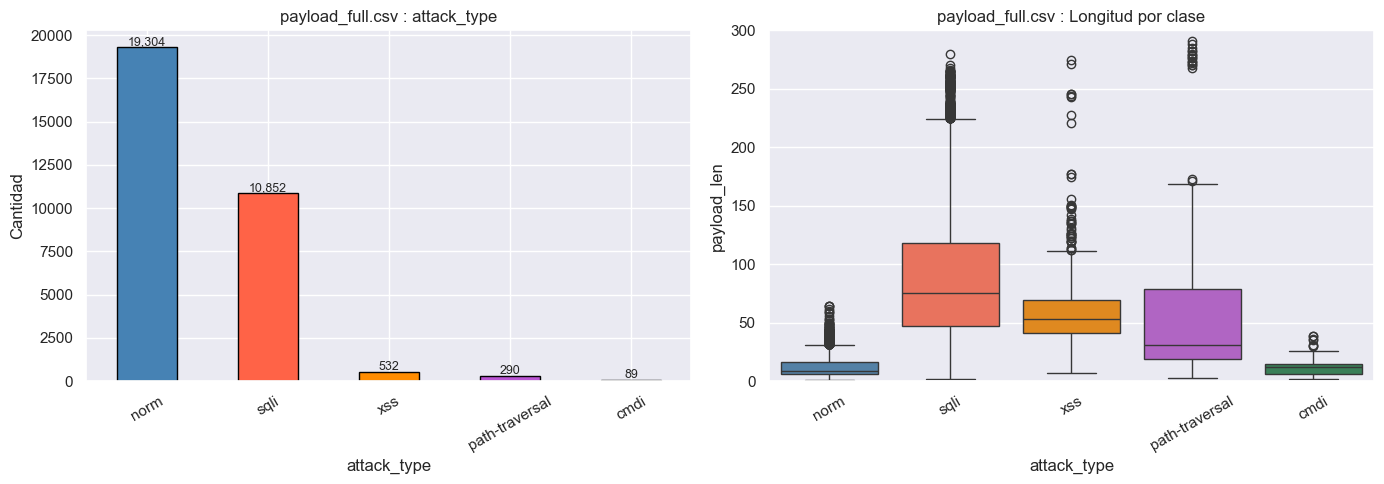


=== Estadisticas de longitud por attack_type ===
                  count   mean    std  min   25%   50%    75%     max
attack_type                                                          
cmdi               89.0   12.8    8.6  2.0   6.0  12.0   15.0    39.0
norm            19304.0   11.8    7.7  1.0   6.0   9.0   16.0    64.0
path-traversal    290.0  114.3  237.9  3.0  19.0  31.0   79.0  1058.0
sqli            10852.0   90.5   56.7  2.0  47.0  75.0  118.0   280.0
xss               532.0   63.2   43.6  7.0  41.0  53.0   69.0   457.0


In [29]:
PALETTE = {"norm": "steelblue", "sqli": "tomato", "xss": "darkorange",
           "path-traversal": "mediumorchid", "cmdi": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [PALETTE.get(x, "gray") for x in counts_at.index]
counts_at.plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("payload_full.csv : attack_type")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(counts_at):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

order = counts_at.index.tolist()
sns.boxplot(data=df_full, x="attack_type", y="payload_len",
            order=order, palette=PALETTE, ax=axes[1])
axes[1].set_title("payload_full.csv : Longitud por clase")
axes[1].set_ylim(0, 300)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\n=== Estadisticas de longitud por attack_type ===")
print(df_full.groupby("attack_type")["payload_len"].describe().round(1))

## Resumen: payload_full.csv

- Filas: 31,067   |   Dupes: 0   |   Nulos: 0   |   Encoding: utf-8
- norm: 19,304 (62.1%)   sqli: 10,852 (34.9%)   xss: 532 (1.7%)   pt: 290 (0.9%)   cmdi: 89 (0.3%)
- Unico CSV que cubre los 4 vectores del proyecto
- Desbalance severo entre vectores: sqli supera en 122:1 a cmdi
- La clase legitimate son direcciones en espanol: no representa trafico HTTP real
- Columnas: `payload` + `attack_type` (5 clases) + `label` (norm/anom) + `length`

# Seccion 4: command_injection.csv

Dataset binario para Command Injection. Label=1 son payloads CMDI (algunos HTML-encoded).
Label=0 son strings normales con distribucion identica a `norm` de payload_full
(misma fuente de datos legitimos: direcciones en espanol).
Codificacion latin-1.

In [30]:
df_cmdi = pd.read_csv(SOURCES["csv/command_injection"], encoding="latin-1")
df_cmdi["payload_len"] = df_cmdi["sentence"].str.len()

dupes = df_cmdi.duplicated().sum()
counts = df_cmdi["Label"].value_counts()

print(f"Shape      : {df_cmdi.shape}")
print(f"Duplicados : {dupes:,}  ({dupes/len(df_cmdi)*100:.2f}%)")
print(f"Nulos      : {df_cmdi.isnull().sum().to_dict()}")
print()
print("=== Distribucion Label ===")
for k, v in counts.items():
    label = {1: 'cmdi', 0: 'legitimate'}.get(k, '?')
    print(f"  Label={k} ({label:<12}) : {v:>5,}  ({v/len(df_cmdi)*100:.1f}%)")
print()
print("=== Estadisticas de longitud ===")
print(df_cmdi.groupby("Label")["payload_len"].describe().round(1))
print()
print("Muestras Label=1 (cmdi):")
for s in df_cmdi[df_cmdi["Label"]==1]["sentence"].head(4):
    print(" ", repr(str(s)[:110]))

Shape      : (2106, 3)
Duplicados : 46  (2.18%)
Nulos      : {'sentence': 1, 'Label': 0, 'payload_len': 1}

=== Distribucion Label ===
  Label=0 (legitimate  ) : 1,591  (75.5%)
  Label=1 (cmdi        ) :   515  (24.5%)

=== Estadisticas de longitud ===
        count  mean    std  min   25%   50%   75%     max
Label                                                    
0      1591.0  11.0    7.2  1.0   6.0   9.0  13.0    47.0
1       514.0  38.6  134.5  1.0  10.0  15.0  32.0  1524.0

Muestras Label=1 (cmdi):
  '&lt;!--#exec%20cmd=&quot;/bin/cat%20/etc/passwd&quot;--&gt;'
  '&lt;!--#exec%20cmd=&quot;/bin/cat%20/etc/shadow&quot;--&gt;'
  '&lt;!--#exec%20cmd=&quot;/usr/bin/id;--&gt;'
  '&lt;!--#exec%20cmd=&quot;/usr/bin/id;--&gt;'


C:\Users\thiag\AppData\Local\Temp\ipykernel_26968\722919059.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_p, x="label_str", y="payload_len",


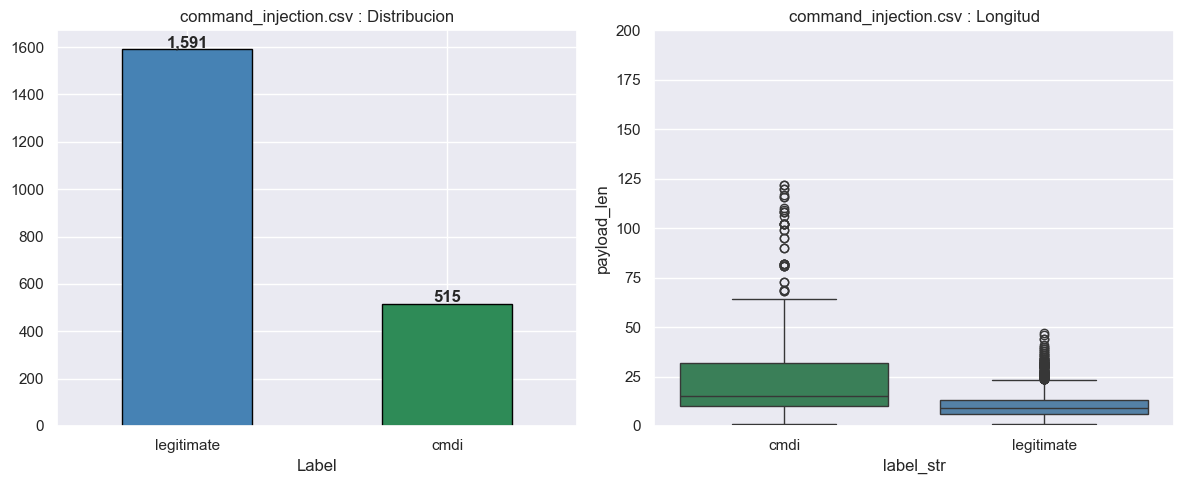

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts.rename({0: "legitimate", 1: "cmdi"}).plot(
    kind="bar", ax=axes[0],
    color=["seagreen" if k==1 else "steelblue" for k in counts.index],
    edgecolor="black")
axes[0].set_title("command_injection.csv : Distribucion")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, f"{v:,}", ha="center", fontweight="bold")

df_p = df_cmdi.dropna(subset=["sentence"]).copy()
df_p["label_str"] = df_p["Label"].map({0: "legitimate", 1: "cmdi"})
sns.boxplot(data=df_p, x="label_str", y="payload_len",
            palette={"legitimate": "steelblue", "cmdi": "seagreen"}, ax=axes[1])
axes[1].set_title("command_injection.csv : Longitud")
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

## Resumen: command_injection.csv

- Filas: 2,106   |   Dupes: 46 (2.2%)   |   Nulos: 1   |   Encoding: latin-1
- cmdi (Label=1): 515 (24.5%)   |   legitimate (Label=0): 1,591 (75.5%)
- Volumen critico: 515 muestras de ataque, insuficiente por si solo
- Payloads HTML-encoded en varios casos: requiere HTML-decode + URL-decode antes de combinar
- Clase legitimate identica en distribucion a `norm` de payload_full: mismo origen sintetico
- Esquema compatible con payload_full tras mapeo: sentence -> payload, Label -> attack_type

# Seccion 5: XSS_dataset.csv

Dataset binario XSS. Label=1 son payloads XSS puros y cortos.
Label=0 son fragmentos de texto HTML de Wikipedia (articulos enciclopedicos),
no trafico HTTP de aplicacion web. Esto introduce un sesgo de longitud
y un sesgo de dominio que puede inflar artificialmente las metricas.

In [32]:
df_xss = pd.read_csv(SOURCES["csv/XSS_dataset"], encoding="utf-8", low_memory=False)
df_xss["payload_len"] = df_xss["Sentence"].str.len()

counts = df_xss["Label"].value_counts()
print(f"Shape      : {df_xss.shape}")
print(f"Duplicados : {df_xss.duplicated().sum():,}")
print(f"Nulos      : {df_xss.isnull().sum().to_dict()}")
print()
print("=== Distribucion Label ===")
for k, v in counts.items():
    label = {1: 'xss', 0: 'legitimate'}.get(k, '?')
    print(f"  Label={k} ({label:<12}) : {v:>6,}  ({v/len(df_xss)*100:.1f}%)")
print()
print("=== Estadisticas de longitud ===")
print(df_xss.groupby("Label")["payload_len"].describe().round(1))

Shape      : (13686, 4)
Duplicados : 0
Nulos      : {'Unnamed: 0': 0, 'Sentence': 0, 'Label': 0, 'payload_len': 0}

=== Distribucion Label ===
  Label=1 (xss         ) :  7,373  (53.9%)
  Label=0 (legitimate  ) :  6,313  (46.1%)

=== Estadisticas de longitud ===
        count   mean    std  min   25%   50%    75%     max
Label                                                      
0      6313.0  162.6  294.5  1.0  20.0  89.0  123.0  5911.0
1      7373.0   62.4   32.6  5.0  42.0  52.0   65.0   425.0


C:\Users\thiag\AppData\Local\Temp\ipykernel_26968\3640123898.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_xss_p, x="label_str", y="payload_len",


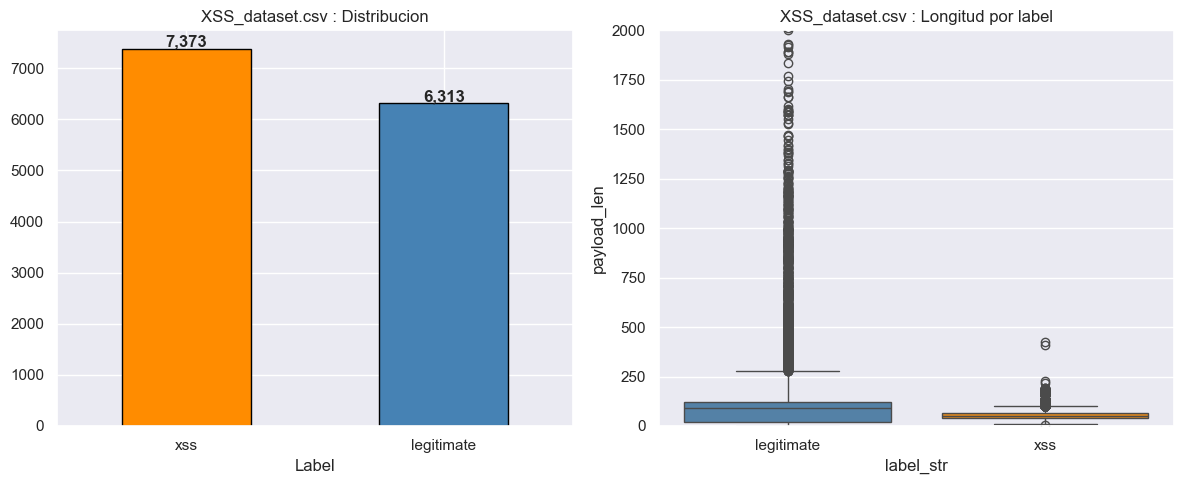


Muestras Label=0 (legitimate - texto Wikipedia):
  '<li><a href="/wiki/File:Socrates.png" class="image"><img alt="Socrates.png" src="//upload.wikimedia.org/wikipedia/commons/thumb/c/'
  '\t </span> <span class="reference-text">Steering for the 1995 "<a href="/wiki/History_of_autonomous_cars#1990s" class="mw-redirect"'
  '\t </span> <span class="reference-text"><cite class="citation web"><a rel="nofollow" class="external text" href="https://www.milese'


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts.rename({0: "legitimate", 1: "xss"}).plot(
    kind="bar", ax=axes[0],
    color=["darkorange" if k==1 else "steelblue" for k in counts.index],
    edgecolor="black")
axes[0].set_title("XSS_dataset.csv : Distribucion")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

df_xss_p = df_xss.copy()
df_xss_p["label_str"] = df_xss_p["Label"].map({0: "legitimate", 1: "xss"})
sns.boxplot(data=df_xss_p, x="label_str", y="payload_len",
            palette={"legitimate": "steelblue", "xss": "darkorange"}, ax=axes[1])
axes[1].set_title("XSS_dataset.csv : Longitud por label")
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.show()

print("\nMuestras Label=0 (legitimate - texto Wikipedia):")
for s in df_xss[df_xss["Label"]==0]["Sentence"].head(3):
    print(" ", repr(str(s)[:130]))

## Resumen: XSS_dataset.csv

- Filas: 13,686   |   Dupes: 0   |   Nulos: 0   |   Encoding: utf-8
- xss (Label=1): 7,373 (53.9%)   |   legitimate (Label=0): 6,313 (46.1%)
- Balance casi perfecto (mejor de todos los CSVs)
- Problema critico: Label=0 son textos HTML de Wikipedia, no peticiones HTTP
  El clasificador puede aprender longitud como proxy de clase, no semantica de ataque
- Columna extra `Unnamed: 0` es indice de fila: descartar
- Usar con precaucion y monitorear feature importance de longitud en validacion

# Seccion 6: data_capec_multilabel.csv

El dataset mas grande: 907,815 registros de peticiones HTTP completas con
etiquetado multi-label basado en categorias CAPEC.
Schema completamente diferente al resto: no combinable directamente.

Vectores CAPEC in-scope para logSguarDian:
- `66 - SQL Injection`        -> sqli
- `88 - OS Command Injection` -> cmdi
- `126 - Path Traversal`      -> path_traversal
- `242 - Code Injection`      -> candidato xss (requiere validacion por inspeccion)
- `248 - Command Injection`   -> 1 sola muestra: descartar

In [34]:
df_capec = pd.read_csv(SOURCES["csv/data_capec"], low_memory=False)

http_cols = [c for c in df_capec.columns if c.startswith(("request", "response", "timestamp", "src", "dst"))]
label_cols = [c for c in df_capec.columns if c not in http_cols]

print(f"Shape      : {df_capec.shape}")
print(f"Duplicados : {df_capec.duplicated().sum():,}")
print()
print("=== Distribucion etiquetas CAPEC ===")
for col in label_cols:
    n = int(df_capec[col].sum())
    pct = n/len(df_capec)*100
    flag = " <- IN-SCOPE" if col in ["66 - SQL Injection","88 - OS Command Injection","126 - Path Traversal","242 - Code Injection"] else ""
    print(f"  {col:<45} : {n:>7,}  ({pct:.2f}%){flag}")

Shape      : (907815, 38)
Duplicados : 2,746

=== Distribucion etiquetas CAPEC ===
  000 - Normal                                  : 525,195  (57.85%)
  272 - Protocol Manipulation                   :   9,153  (1.01%)
  242 - Code Injection                          :  15,827  (1.74%) <- IN-SCOPE
  88 - OS Command Injection                     :   7,482  (0.82%) <- IN-SCOPE
  126 - Path Traversal                          :  20,992  (2.31%) <- IN-SCOPE
  66 - SQL Injection                            : 250,311  (27.57%) <- IN-SCOPE
  16 - Dictionary-based Password Attack         :   1,847  (0.20%)
  310 - Scanning for Vulnerable Software        :   2,718  (0.30%)
  153 - Input Data Manipulation                 :   2,272  (0.25%)
  248 - Command Injection                       :       1  (0.00%)
  274 - HTTP Verb Tampering                     :   5,437  (0.60%)
  194 - Fake the Source of Data                 :  56,145  (6.18%)
  34 - HTTP Response Splitting                  :  19,738  (2.1

In [35]:
IN_SCOPE = {"66 - SQL Injection": "sqli", "88 - OS Command Injection": "cmdi",
            "126 - Path Traversal": "path_traversal", "242 - Code Injection": "code_injection"}

attack_cols = [c for c in label_cols if c != "000 - Normal"]
n_per_row   = df_capec[attack_cols].sum(axis=1)

print("=== Multi-label: ataques por fila ===")
for n, count in sorted(n_per_row.value_counts().items()):
    print(f"  {int(n)} ataques : {count:>7,} filas")

print()
inscope_any = df_capec[list(IN_SCOPE.keys())].sum(axis=1) > 0
print(f"In-scope total          : {inscope_any.sum():>7,}")
print(f"Normal puro (sin ataque): {(~inscope_any).sum():>7,}")
print()
# Nulos en columnas clave
key_cols = ["request_http_method", "request_http_request", "request_body", "response_http_status_code"]
null_pct = (df_capec[key_cols].isnull().sum() / len(df_capec) * 100).round(1)
print("=== Nulos en columnas HTTP clave ===")
print(null_pct.to_string())

=== Multi-label: ataques por fila ===
  0 ataques : 525,195 filas
  1 ataques : 373,382 filas
  2 ataques :   8,132 filas
  3 ataques :   1,088 filas
  4 ataques :      18 filas

In-scope total          : 289,286
Normal puro (sin ataque): 618,529

=== Nulos en columnas HTTP clave ===
request_http_method           0.0
request_http_request          0.0
request_body                 97.1
response_http_status_code     0.0


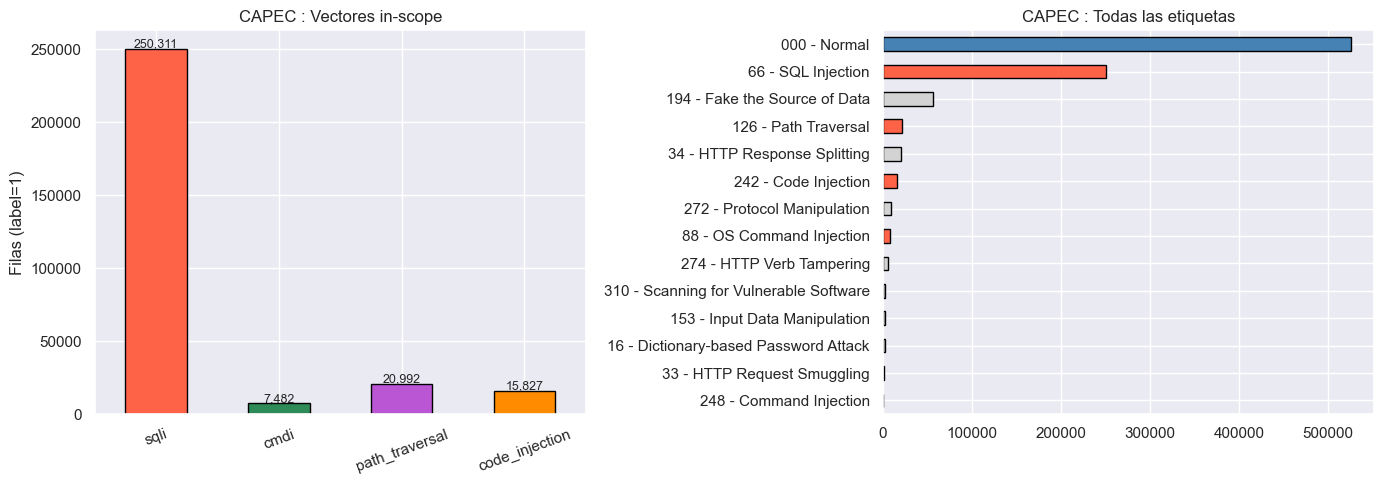

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inscope_counts = pd.Series({alias: int(df_capec[col].sum()) for col, alias in IN_SCOPE.items()})
inscope_counts.plot(kind="bar", ax=axes[0],
                    color=["tomato","seagreen","mediumorchid","darkorange"], edgecolor="black")
axes[0].set_title("CAPEC : Vectores in-scope")
axes[0].set_ylabel("Filas (label=1)")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(inscope_counts):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=9)

all_counts = pd.Series({c: int(df_capec[c].sum()) for c in label_cols}).sort_values()
colors_bar = ["tomato" if c in IN_SCOPE else "steelblue" if c=="000 - Normal" else "lightgray"
              for c in all_counts.index]
all_counts.plot(kind="barh", ax=axes[1], color=colors_bar, edgecolor="black")
axes[1].set_title("CAPEC : Todas las etiquetas")

plt.tight_layout()
plt.show()

## Resumen: data_capec_multilabel.csv

- Filas: 907,815   |   Dupes: 2,746   |   Nulos criticos: 2
- Schema: 38 columnas (peticion HTTP completa + 14 labels CAPEC multi-label)

In-scope:
  - SQLi (66)            : 250,311  (27.6%)
  - Path Traversal (126) :  20,992  (2.3%)
  - Code Injection (242) :  15,827  (1.7%)  -> verificar si es XSS o PHP injection
  - CMDI (88)            :   7,482  (0.8%)
  - Normal (000)         : 525,195  (57.8%)
  - Command Injection (248): 1 muestra -> descartar

Observaciones criticas:
- Schema incompatible con los CSVs de payload: requiere extraccion de request_http_request + request_body
- request_body nulo en 97% de filas: la mayoria de ataques estan en la URL
- SQLi esta sobrerrepresentado respecto a cmdi (33:1)
- `242 - Code Injection` puede incluir PHP injection, no solo XSS: verificar por inspeccion manual

# Seccion 7: modsec-learn JSON

Dos archivos JSON de la libreria modsec-learn: listas planas de strings.
- `legitimate_dataset.json`: query strings de trafico real (modsecurity logs de produccion)
- `malicious_dataset.json`: payloads SQLi extraidos de logs de ataques reales

Es la unica fuente con trafico HTTP legitimo real (no sintetico) en formato de query string.

In [37]:
with open(SOURCES["json/legitimate"], encoding="utf-8") as f:
    legit_raw = json.load(f)
with open(SOURCES["json/malicious_sqli"], encoding="utf-8") as f:
    sqli_raw = json.load(f)

legit_unique = list(dict.fromkeys(legit_raw))  # preserva orden, elimina dupes
sqli_unique  = list(dict.fromkeys(sqli_raw))

legit_lens  = [len(s) for s in legit_unique]
sqli_lens   = [len(s) for s in sqli_unique]

print("=== legitimate_dataset.json ===")
print(f"  Entradas totales : {len(legit_raw):,}")
print(f"  Duplicados       : {len(legit_raw)-len(legit_unique):,}  ({(len(legit_raw)-len(legit_unique))/len(legit_raw)*100:.1f}%)")
print(f"  Entradas unicas  : {len(legit_unique):,}")
print(f"  Tipo             : {type(legit_raw[0]).__name__} (query strings URL-encoded)")
print(f"  Len media/med/max: {sum(legit_lens)/len(legit_lens):.0f} / {sorted(legit_lens)[len(legit_lens)//2]} / {max(legit_lens)}")

print()
print("=== malicious_dataset.json (sqli) ===")
print(f"  Entradas totales : {len(sqli_raw):,}")
print(f"  Duplicados       : {len(sqli_raw)-len(sqli_unique):,}")
print(f"  Entradas unicas  : {len(sqli_unique):,}")
print(f"  Len media/med/max: {sum(sqli_lens)/len(sqli_lens):.0f} / {sorted(sqli_lens)[len(sqli_lens)//2]} / {max(sqli_lens)}")

print()
print(f"Ratio legitimate:sqli (unicos) = {len(legit_unique)/len(sqli_unique):.2f}:1")

=== legitimate_dataset.json ===
  Entradas totales : 508,530
  Duplicados       : 439,429  (86.4%)
  Entradas unicas  : 69,101
  Tipo             : str (query strings URL-encoded)
  Len media/med/max: 495 / 314 / 31673

=== malicious_dataset.json (sqli) ===
  Entradas totales : 30,544
  Duplicados       : 0
  Entradas unicas  : 30,544
  Len media/med/max: 178 / 132 / 2813

Ratio legitimate:sqli (unicos) = 2.26:1


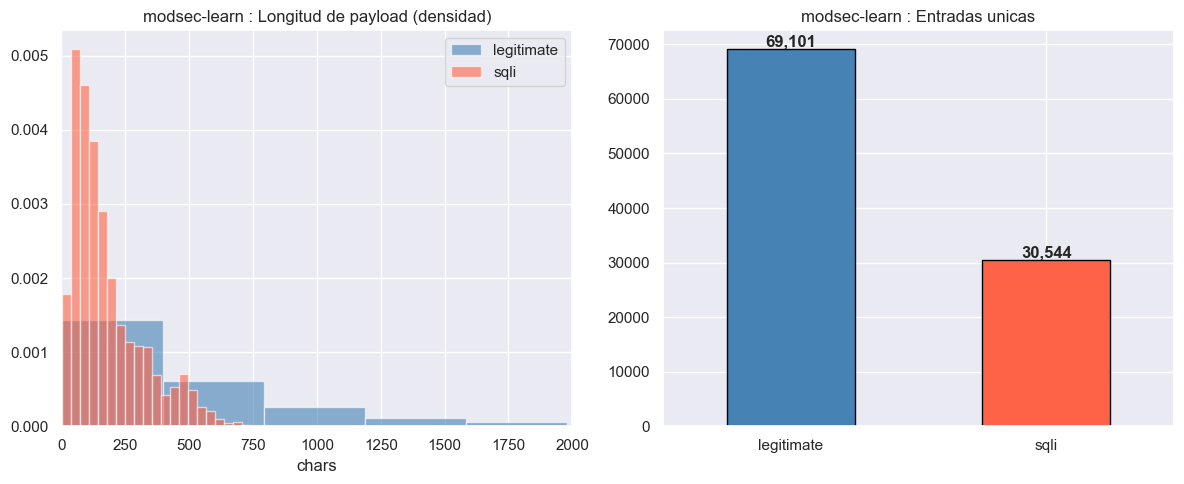


Muestras legitimate (decodificadas):
  'source[action]=show&source[app]=Shopify&source[controller]=checkouts/web/checkouts&source[section]=c'
  'v=1645527473'
  'origin=onetag&domain=365mashbir.co.il&sn=ChromeSyncframe&so=3&topUrl=365mashbir.co.il&bundle=ldVXDl9hS0VDdENtdzZsT1V1aHV'
  'random=1660540144644&cv=9&fst=1660539600000&num=1&bg=ffffff&guid=ON&eid=376635470&u_h=1080&u_w=1920&u_ah=1040&u_aw=1920&'

Muestras sqli:
  "p=\x00'' UNION SELECT password FROM Users WHERE username-''foobar''--"
  "p=\x00' UNION SELECT password FROM Users WHERE username-'tom'--"
  'p=\n\r+select+user+from+dual+\n\r'
  'p=\nselect 0x00, 0x41 like/*!31337table_name*/,3 from information_schema.tables limit 1'


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(legit_lens,  bins=80, alpha=0.6, color="steelblue",  label="legitimate", density=True)
axes[0].hist(sqli_lens,   bins=80, alpha=0.6, color="tomato",     label="sqli",       density=True)
axes[0].set_title("modsec-learn : Longitud de payload (densidad)")
axes[0].set_xlabel("chars")
axes[0].set_xlim(0, 2000)
axes[0].legend()

counts_json = pd.Series({"legitimate": len(legit_unique), "sqli": len(sqli_unique)})
counts_json.plot(kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_title("modsec-learn : Entradas unicas")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts_json):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nMuestras legitimate (decodificadas):")
for s in legit_unique[:4]:
    print(" ", repr(unquote(s[:120])))

print("\nMuestras sqli:")
for s in sqli_unique[:4]:
    print(" ", repr(unquote(s[:120])))

## Resumen: modsec-learn JSON

- legitimate_dataset.json: 508,530 entradas -> 69,101 unicas tras deduplicar (86.4% dupes)
  - Query strings de trafico web real (Shopify, Google Analytics, etc.)
  - Es la unica fuente de trafico legitimo que NO es sintetica
  - Codificacion URL: requiere unquote para analisis

- malicious_dataset.json: 30,544 entradas, 0 duplicados
  - Exclusivamente SQLi (UNION SELECT, blind injection, etc.)
  - Formato: `p=<payload>` (parametro con payload incrustado)
  - Longitud media 178 chars, max 2,813 chars

Acciones requeridas:
- legitimate: eliminar 439,429 duplicados antes de usar
- malicious: directamente usable como sqli
- Mapeo de schema: payload=string, label={legitimate, sqli}

# Seccion 8: Path Traversal Wordlists (omurugur)

Carpeta con 9 archivos .txt del repositorio `omurugur/Path_Traversal_Payload_List`.

ADVERTENCIA: la mayoria de estos archivos NO son payloads de Path Traversal.
Son listas de enumeracion de directorios/archivos (wordlists para dirbusting),
usadas por herramientas como dirb o dirbuster.
Solo dos archivos contienen payloads de traversal reales.

In [39]:
PT_DIR = SOURCES["txt/pt_wordlists_dir"]
txt_files = sorted(PT_DIR.glob("*.txt"))

all_lines_dict = {}

for f in txt_files:
    lines = f.read_text(encoding="utf-8", errors="replace").splitlines()
    lines = [l for l in lines if l.strip()]
    all_lines_dict[f.name] = lines

# Clasificacion manual basada en contenido
CLASSIFICATION = {
    "Deep-Travelsal.txt"     : "TEMPLATE (usa {FILE}, no es payload directo)",
    "Dp.txt"                 : "PAYLOAD PT real (Windows: \\..\\..\\WINDOWS\\win.ini)",
    "all-asp.txt"            : "ENUMERACION (filenames .asp, no es PT)",
    "all-aspx.txt"           : "ENUMERACION (filenames .aspx, no es PT)",
    "all-extensionless.txt"  : "ENUMERACION (filenames sin extension, no es PT)",
    "all-jsp.txt"            : "ENUMERACION (filenames .jsp, no es PT)",
    "all-php.txt"            : "ENUMERACION (filenames .php, no es PT)",
    "all.txt"                : "ENUMERACION (rutas comunes, no es PT)",
    "jslogin.txt"            : "ENUMERACION (login pages, no es PT)",
}

print(f"{'Archivo':<35}  {'Lineas':>8}  Tipo")
print("-" * 90)
for fname, lines in all_lines_dict.items():
    cls = CLASSIFICATION.get(fname, "?")
    print(f"  {fname:<33}  {len(lines):>8,}  {cls}")

all_flat = [l for lines in all_lines_dict.values() for l in lines]
print(f"\nTotal lineas (todos los archivos) : {len(all_flat):,}")
print(f"Unicas cross-file                 : {len(set(all_flat)):,}")

Archivo                                Lineas  Tipo
------------------------------------------------------------------------------------------
  all-asp.txt                          25,353  ENUMERACION (filenames .asp, no es PT)
  all-aspx.txt                         25,418  ENUMERACION (filenames .aspx, no es PT)
  all-extensionless.txt                25,420  ENUMERACION (filenames sin extension, no es PT)
  all-jsp.txt                          25,419  ENUMERACION (filenames .jsp, no es PT)
  all-php.txt                          25,419  ENUMERACION (filenames .php, no es PT)
  all.txt                              43,136  ENUMERACION (rutas comunes, no es PT)
  Deep-Travelsal.txt                      879  TEMPLATE (usa {FILE}, no es payload directo)
  Dp.txt                                1,166  PAYLOAD PT real (Windows: \..\..\WINDOWS\win.ini)
  jslogin.txt                             294  ENUMERACION (login pages, no es PT)

Total lineas (todos los archivos) : 172,504
Unicas cross-fi

In [40]:
print("=== Deep-Travelsal.txt (primeras 8 lineas) ===")
for l in all_lines_dict["Deep-Travelsal.txt"][:8]:
    print(f"  {repr(l)}")

print()
print("=== Dp.txt (primeras 8 lineas) ===")
for l in all_lines_dict["Dp.txt"][:8]:
    print(f"  {repr(l)}")

print()
print("=== all-php.txt (primeras 5 lineas - ENUMERACION, no PT) ===")
for l in all_lines_dict["all-php.txt"][:5]:
    print(f"  {repr(l)}")

=== Deep-Travelsal.txt (primeras 8 lineas) ===
  '../{FILE}'
  '../../{FILE}'
  '../../../{FILE}'
  '../../../../{FILE}'
  '../../../../../{FILE}'
  '../../../../../../{FILE}'
  '../../../../../../../{FILE}'
  '../../../../../../../../{FILE}'

=== Dp.txt (primeras 8 lineas) ===
  '\\..\\WINDOWS\\win.ini'
  '\\..\\..\\WINDOWS\\win.ini'
  '\\..\\..\\..\\WINDOWS\\win.ini'
  '\\..\\..\\..\\..\\WINDOWS\\win.ini'
  '\\..\\..\\..\\..\\..\\WINDOWS\\win.ini'
  '\\..\\..\\..\\..\\..\\..\\WINDOWS\\win.ini'
  '%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%57%49%4e%44%4f%57%53%5c%77%69%6e%2e%69%6e%69'
  '%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%2e%2e%5c%57%49%4e%44%4f%57%53%5c%77%69%6e%2e%69%6e%69'

=== all-php.txt (primeras 5 lineas - ENUMERACION, no PT) ===
  'home.php'
  'setup.php'
  'install.php'
  'init.php'
  'en.php'


## Resumen: Path Traversal Wordlists

Archivos realmente utiles para el dataset de path_traversal:
  - `Dp.txt`             : 1,166 payloads de traversal (Windows paths: `\\..\\..\\WINDOWS\\win.ini`)
  - `Deep-Travelsal.txt` : 879 templates con `{FILE}` placeholder -> requiere sustitucion
  
Archivos NO utiles (son wordlists de enumeracion de directorios):
  - `all-asp.txt`, `all-aspx.txt`, `all-jsp.txt`, `all-php.txt`, `all-extensionless.txt`:
    ~25,000 lineas c/u de nombres de archivos (home.php, setup.php, etc.)
    Son listas para dirbusting, NO payloads de path traversal
  - `all.txt`   : 43,136 rutas comunes (CVS, .git/config, root)
  - `jslogin.txt`: 294 rutas de login (admin.jsp, login.html)

Acciones requeridas:
- Usar solo Dp.txt (1,166 payloads) y Deep-Travelsal.txt con sustitucion de {FILE}
- Los archivos all-*.txt NO se deben incluir en el dataset como PT payloads
- Fuente label-only (todos son positivos): requiere combinar con clase legitimate de otra fuente

# Seccion 9: OWASP ModSecurity Logs

30 dias de logs de ModSecurity/Apache con 142,705 transacciones HTTP.
Formato: bloques de transaccion separados por `--[hash]-A--`.
La seccion `-H--` contiene los mensajes de las reglas disparadas (tags + IDs).

Nota sobre la clasificacion de `path_traversal`:
El tag `attack-lfi` cubre dos tipos distintos en CRS 3.2:
- Rule 930110/930120: traversal clasico (`../../../etc/passwd`)
- Rule 930130: acceso a archivos sensibles (`/.git/config`, `/wp-config.php`, `/.env`)
Ambos se consolidan como `path_traversal` en el label, pero tienen naturaleza diferente.

In [41]:
OWASP_DIR = SOURCES["log/owasp_dir"]
log_files = sorted(OWASP_DIR.rglob("*.anon.log"))

total_size_mb = sum(f.stat().st_size for f in log_files) / (1024**2)
print(f"Archivos encontrados : {len(log_files)}")
print(f"Tamano total         : {total_size_mb:.1f} MB")
print()
for f in log_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.parent.name}  {size_kb:.0f} KB")

Archivos encontrados : 30
Tamano total         : 379.5 MB

  01-Aug-2025  15332 KB
  02-Aug-2025  13683 KB
  03-Aug-2025  13368 KB
  04-Aug-2025  18605 KB
  05-Aug-2025  11996 KB
  06-Aug-2025  9429 KB
  07-Aug-2025  5085 KB
  08-Aug-2025  6804 KB
  09-Aug-2025  9116 KB
  10-Aug-2025  18472 KB
  11-Aug-2025  8714 KB
  12-Aug-2025  6540 KB
  13-Aug-2025  14441 KB
  14-Aug-2025  24688 KB
  15-Aug-2025  29120 KB
  16-Aug-2025  27940 KB
  17-Aug-2025  16460 KB
  18-Aug-2025  9338 KB
  19-Aug-2025  10741 KB
  20-Aug-2025  7574 KB
  21-Aug-2025  7673 KB
  22-Aug-2025  7471 KB
  23-Aug-2025  9998 KB
  24-Aug-2025  8954 KB
  25-Aug-2025  9343 KB
  27-Jul-2025  7695 KB
  28-Jul-2025  33362 KB
  29-Jul-2025  7687 KB
  30-Jul-2025  8064 KB
  31-Jul-2025  10942 KB


In [42]:
def classify_owasp(tags, rule_ids):
    """Clasifica una transaccion OWASP segun tags y rule IDs de CRS."""
    if "attack-sqli" in tags:
        return "sqli"
    if "attack-xss" in tags:
        return "xss"
    # 930110 = ../  traversal, 930120 = path segments, 930130 = sensitive files (.git, wp-config)
    if any(r in rule_ids for r in ["930110", "930120", "930130"]) or "attack-lfi" in tags or "attack-rfi" in tags:
        return "path_traversal"
    # 932150/932160 = RCE Unix 
    if any(r in rule_ids for r in ["932150", "932160"]) or "attack-rce" in tags:
        return "cmdi"
    return "out_of_scope"

label_counter = Counter()
tag_counter   = Counter()
rule_counter  = Counter()
samples       = {"sqli": [], "xss": [], "path_traversal": [], "cmdi": []}
total_tx      = 0

for log_file in log_files:
    with open(log_file, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    
    for tx in re.split(r"(?=--[a-f0-9]+-A--)", content):
        if not tx.strip():
            continue
        
        sec_h = re.search(r"-H--\n(.*?)(?=--[a-f0-9]+-Z--|$)", tx, re.DOTALL)
        if not sec_h:
            continue
        
        h = sec_h.group(1)
        tags     = set(re.findall(r'\[tag "([^"]+)"\]', h))
        rule_ids = set(re.findall(r'\[id "(\d+)"\]', h))
        label    = classify_owasp(tags, rule_ids)
        
        label_counter[label] += 1
        tag_counter.update(tags)
        if label != "out_of_scope":
            rule_counter.update(rule_ids)
        
        if label in samples and len(samples[label]) < 3:
            sec_b = re.search(r"-B--\n(.+)", tx)
            if sec_b:
                samples[label].append(sec_b.group(1).strip().split("\n")[0][:120])
        
        total_tx += 1

print(f"Total transacciones : {total_tx:,}")
print()
print("=== Distribucion de labels ===")
for k, v in label_counter.most_common():
    print(f"  {k:<25} : {v:>7,}  ({v/total_tx*100:.2f}%)")

Total transacciones : 142,705

=== Distribucion de labels ===
  out_of_scope              :  86,201  (60.41%)
  path_traversal            :  49,849  (34.93%)
  sqli                      :   4,064  (2.85%)
  cmdi                      :   2,331  (1.63%)
  xss                       :     260  (0.18%)


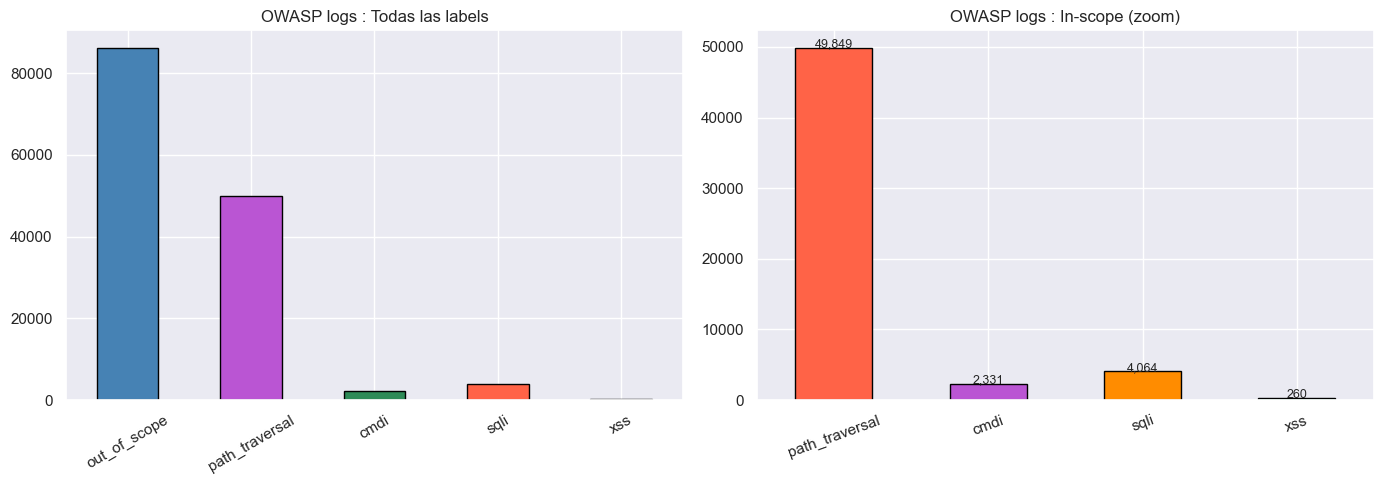


=== Muestras por categoria ===
  [sqli]
    'POST /wp-login.php HTTP/1.1'
    'GET / HTTP/1.1'
    'GET /xmlrpc.php?rsd HTTP/1.1'
  [xss]
    'GET /d_eac5f762/d_5d804804?Itemid=91&catid=46%3Aepitesi-tanacsok&id=%3Cscript%3Ealert%28%27XSS%27%29%3C%2Fscript%3E&opti'
    'GET /d_eac5f762/d_5d804804?Itemid=91&catid=%3Cscript%3Ealert%28%27XSS%27%29%3C%2Fscript%3E&id=2719%3Aaz-uj-szemlelet-sik'
    'GET /d_eac5f762/d_5d804804?Itemid=%3Cscript%3Ealert%28%27XSS%27%29%3C%2Fscript%3E&catid=46%3Aepitesi-tanacsok&id=2719%3A'
  [path_traversal]
    'GET /.git/config HTTP/1.1'
    'GET /wp-config.php HTTP/1.1'
    'GET /wp-config.php HTTP/1.1'
  [cmdi]
    'POST /wp-plain.php HTTP/1.1'
    'GET /cizpksfd.php?Fox=d3wL7 HTTP/1.1'
    'POST /wp-plain.php HTTP/1.1'

=== Top 10 rule IDs in-scope ===
  930130   48,216   Sensitive File Access (.git/.env/wp-config)
  942100    3,978   SQL Injection (libinjection)
  920450    3,091   
  920440    2,202   
  942360    2,153   SQL Injection (concatenation)
  

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inscope_labels = {k: v for k, v in label_counter.items() if k != "out_of_scope"}
oos_count      = label_counter["out_of_scope"]

all_labels = pd.Series(dict(label_counter))
colors_all = ["steelblue" if k == "out_of_scope" else
              {"sqli":"tomato","xss":"darkorange","path_traversal":"mediumorchid","cmdi":"seagreen"}.get(k,"gray")
              for k in all_labels.index]
all_labels.plot(kind="bar", ax=axes[0], color=colors_all, edgecolor="black")
axes[0].set_title("OWASP logs : Todas las labels")
axes[0].tick_params(axis="x", rotation=30)

inscope_ser = pd.Series(inscope_labels)
inscope_colors = ["tomato","mediumorchid","darkorange","seagreen"][:len(inscope_ser)]
inscope_ser.plot(kind="bar", ax=axes[1], color=inscope_colors, edgecolor="black")
axes[1].set_title("OWASP logs : In-scope (zoom)")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(inscope_ser):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Muestras por categoria ===")
for lbl, samps in samples.items():
    print(f"  [{lbl}]")
    for s in samps:
        print(f"    {repr(s)}")

print()
print("=== Top 10 rule IDs in-scope ===")
RULE_NAMES = {
    "930110": "Path Traversal (../)",
    "930120": "Path Traversal (segments)",
    "930130": "Sensitive File Access (.git/.env/wp-config)",
    "932150": "RCE: Unix Command Found",
    "932160": "RCE: Unix Shell Code Found",
    "942100": "SQL Injection (libinjection)",
    "942360": "SQL Injection (concatenation)",
    "941120": "XSS (event handlers)",
}
for rid, cnt in rule_counter.most_common(10):
    name = RULE_NAMES.get(rid, "")
    print(f"  {rid}  {cnt:>7,}   {name}")

## Resumen: OWASP Logs

- Archivos : 30   |   Tamano total: 379.5 MB   |   Total transacciones: 142,705

Distribucion in-scope:
  - path_traversal : 49,849 (34.9%)
  - sqli           :  4,064  (2.8%)
  - cmdi           :  2,331  (1.6%)
  - xss            :    260  (0.2%)
  - out_of_scope   : 86,201  (60.4%)

Matiz critico sobre path_traversal:
  - Rule 930130 dispara 48,216 veces: acceso a archivos sensibles (/.git/config, /wp-config.php, /.env)
    NO es traversal clasico con ../; las muestras capturadas son GET /.git/config, GET /wp-config.php
  - Rule 930120 dispara 1,115 veces: traversal por segmentos de path
  - Rule 930110 (traversal clasico ../) no aparece en el top 10 de reglas disparadas
  Las 49,849 transacciones path_traversal son en su mayoria 930130 (sensitive file access).
  Esto es correcto para la definicion OWASP CRS de LFI, pero debe documentarse en la metodologia:
  el grueso de las muestras NO son ../../etc/passwd, sino reconnaissance de archivos de configuracion.

Sobre cmdi (2,331 transacciones):
  - Rule 932150 (RCE: Unix Command Found) dispara 2,074 veces
  - Las muestras capturadas son POST a scripts PHP con nombres aleatorios (wp-plain.php,
    cizpksfd.php): posibles webshells o shells cargadas, no inyeccion via parametro de aplicacion
  - Para dataset construction: verificar que los payloads reales sean inyecciones en parametro
    y no trafico de post-explotacion

Acciones requeridas:
  - Extraer (method, path, query_string) de cada transaccion in-scope
  - Descartar out_of_scope (86,201 transacciones)
  - Los parquets de exportacion previos estan desactualizados (tenian brute_force, sin path_traversal)

# Seccion 10: RussellMitchell Access Logs

Dataset de un escenario de compromiso de WordPress del 21 al 25 de enero de 2022.
Formato: Apache Combined Log Format (CLF).
Labels disponibles SOLO para .log.2 (dia del ataque activo: 23 enero).
Los otros dias (.log.1, .log.3, .log.4) son trafico sin etiquetar.

EVALUACION: este dataset NO contiene SQLi, XSS, Path Traversal ni Command Injection.
Los labels son: dirb/wpscan (reconnaissance), webshell_cmd (post-exploitation).
Util UNICAMENTE como fuente de trafico HTTP legitimo de WordPress.

In [44]:
RM = SOURCES["log/russellmitchell"]
LOG_DIR    = RM / "gather/intranet_server/logs/apache2"
LABELS_DIR = RM / "labels/intranet_server/logs/apache2"

# Inventario de logs
LOG_FILES = [
    LOG_DIR / "intranet.smith.russellmitchell.com-access.log",
    LOG_DIR / "intranet.smith.russellmitchell.com-access.log.1",
    LOG_DIR / "intranet.smith.russellmitchell.com-access.log.2",
    LOG_DIR / "intranet.smith.russellmitchell.com-access.log.3",
    LOG_DIR / "intranet.smith.russellmitchell.com-access.log.4",
]

print("=== Inventario access logs ===")
for f in LOG_FILES:
    n = sum(1 for _ in open(f, encoding="utf-8", errors="replace")) if f.exists() else 0
    size_kb = f.stat().st_size / 1024 if f.exists() else 0
    has_label = (LABELS_DIR / f.name).exists()
    print(f"  {f.name:<55} {n:>5,} lineas   {size_kb:.0f} KB   labels={'SI' if has_label else 'NO'}")

print()
# Label distribution para .log.2
LABEL_FILE = LABELS_DIR / "intranet.smith.russellmitchell.com-access.log.2"
label_counter_rm = Counter()
n_labeled = 0
with open(LABEL_FILE) as lf:
    for line in lf:
        obj = json.loads(line)
        for lbl in obj["labels"]:
            label_counter_rm[lbl] += 1
        n_labeled += 1

print(f"=== Labels .log.2 ===")
print(f"Lineas etiquetadas : {n_labeled:,}  (de 8,530 totales; 835 sin etiqueta -> legitimate)")
print()
for k, v in label_counter_rm.most_common():
    print(f"  {k:<30} : {v:>5,}")

=== Inventario access logs ===
  intranet.smith.russellmitchell.com-access.log               0 lineas   0 KB   labels=NO
  intranet.smith.russellmitchell.com-access.log.1           601 lineas   146 KB   labels=NO
  intranet.smith.russellmitchell.com-access.log.2         8,530 lineas   1528 KB   labels=SI
  intranet.smith.russellmitchell.com-access.log.3           933 lineas   250 KB   labels=NO
  intranet.smith.russellmitchell.com-access.log.4         1,120 lineas   283 KB   labels=NO

=== Labels .log.2 ===
Lineas etiquetadas : 7,695  (de 8,530 totales; 835 sin etiqueta -> legitimate)

  foothold                       : 7,691
  attacker_http                  : 7,687
  dirb                           : 4,462
  wpscan                         : 3,186
  webshell_cmd                   :    32
  service_scan                   :    12
  escalate                       :     4
  webshell_upload                :     3


In [45]:
import re as _re

LOG_PAT = _re.compile(r'(\S+) \S+ \S+ \[([^\]]+)\] "(\S+) (\S+) \S+" (\d+)')

# Leer .log.2 con labels
label_idx = {}
with open(LABEL_FILE) as lf:
    for line in lf:
        obj = json.loads(line)
        label_idx[obj["line"]] = obj["labels"]

ACCESS_LOG = LOG_DIR / "intranet.smith.russellmitchell.com-access.log.2"
records = []
with open(ACCESS_LOG, encoding="utf-8", errors="replace") as f:
    for line_num, line in enumerate(f, start=1):
        m = LOG_PAT.match(line.strip())
        if not m:
            continue
        src_ip, ts, method, full_path, status = m.groups()
        path = full_path.split("?")[0]
        qs   = full_path.split("?")[1] if "?" in full_path else None
        labels = label_idx.get(line_num, [])
        
        # Clasificacion simplificada
        if "webshell_cmd" in labels:
            label = "webshell_cmd"
        elif labels:  # dirb, wpscan, service_scan, etc.
            label = "recon"
        else:
            label = "legitimate"
        
        records.append({"method": method, "path": path, "query_string": qs,
                        "status_code": int(status), "label": label})

df_rm = pd.DataFrame(records)
print("=== log.2 parseado ===")
print(df_rm["label"].value_counts().to_string())
print()

# Conteo total de trafico legitimo (todas las versiones)
total_legit = 821  # log.2
for fname in ["intranet.smith.russellmitchell.com-access.log.1",
              "intranet.smith.russellmitchell.com-access.log.3",
              "intranet.smith.russellmitchell.com-access.log.4"]:
    f = LOG_DIR / fname
    n = sum(1 for _ in open(f, encoding="utf-8", errors="replace")) if f.exists() else 0
    total_legit += n

print(f"Trafico legitimo total (todos los logs sin ataque) : ~{total_legit:,} lineas")
print()
print("=== Muestras webshell_cmd (post-explotacion) ===")
webshell_lines = df_rm[df_rm["label"]=="webshell_cmd"][["method","path","query_string"]].head(3)
for _, row in webshell_lines.iterrows():
    qs = row['query_string']
    if qs:
        from urllib.parse import unquote
        decoded = unquote(qs)[:80]
        print(f"  {row['method']} {row['path']}?{decoded}")

=== log.2 parseado ===
label
recon           7663
legitimate       821
webshell_cmd      32

Trafico legitimo total (todos los logs sin ataque) : ~3,475 lineas

=== Muestras webshell_cmd (post-explotacion) ===
  GET /wp-content/uploads/2022/01/ekmkimzkps-1642996700.9285.php?wp_meta=WyJ3aG9hbWkiXQ==
  GET /wp-content/uploads/2022/01/ekmkimzkps-1642996700.9285.php?wp_meta=WyJ1bmFtZSIsICItciJd
  GET /wp-content/uploads/2022/01/ekmkimzkps-1642996700.9285.php?wp_meta=WyJjYXQiLCAiL2V0Yy9wcm9maWxlIl0=


## Resumen: RussellMitchell

Escenario: compromiso de WordPress en 5 dias (21-25 enero 2022)
- .log.4 (21-ene): 1,120 lineas, solo legitimo, SIN labels
- .log.3 (22-ene): 933 lineas, solo legitimo, SIN labels
- .log.2 (23-ene): 8,530 lineas, dia del ataque, CON labels
- .log.1 (24-ene): 601 lineas, post-ataque, SIN labels

Labels en .log.2:
  - foothold/attacker_http : 7,691 (superset de todos los ataques)
  - dirb (reconnaissance)  : 4,462
  - wpscan (reconnaissance) : 3,186
  - webshell_cmd            :    32 (post-explotacion, no Command Injection por input)
  - webshell_upload         :     3
  - service_scan/escalate   :    16
  - legitimate (sin label)  :   835

Conclusion:
  NINGUNO de los 4 vectores del proyecto tiene label en este dataset.
  webshell_cmd son comandos ejecutados via webshell ya instalada (post-explotacion),
  NO es Command Injection por inyeccion en parametro de aplicacion.

Uso valido:
  - Trafico legitimo de WordPress: ~2,654 lineas de .log.1/.log.3/.log.4 sin etiquetar
  - 821 lineas legitimate de .log.2
  - Total aporte: ~3,475 peticiones HTTP legitimas de WordPress (real, no sintetico)

# Seccion 12: Analisis de compatibilidad y cobertura

Mapa completo de todas las fuentes contra los cuatro vectores del proyecto.

In [46]:
# Muestras de ataque disponibles por vector y fuente
coverage = pd.DataFrame([
    {"fuente":"Payloads.csv",         "sqli":0,       "xss":15_149, "pt":0,      "cmdi":0},
    {"fuente":"payload_full.csv",     "sqli":10_852,  "xss":532,    "pt":290,    "cmdi":89},
    {"fuente":"command_injection.csv","sqli":0,       "xss":0,      "pt":0,      "cmdi":515},
    {"fuente":"XSS_dataset.csv",      "sqli":0,       "xss":7_373,  "pt":0,      "cmdi":0},
    {"fuente":"data_capec.csv",       "sqli":250_311, "xss":0,      "pt":20_992, "cmdi":7_482},
    {"fuente":"modsec-learn JSON",    "sqli":30_544,  "xss":0,      "pt":0,      "cmdi":0},
    {"fuente":"PT wordlists",         "sqli":0,       "xss":0,      "pt":1_166,  "cmdi":0},
    {"fuente":"OWASP logs",           "sqli":4_064,   "xss":260,    "pt":49_849, "cmdi":2_331},
    {"fuente":"RussellMitchell",      "sqli":0,       "xss":0,      "pt":0,      "cmdi":0},
]).set_index("fuente")

print("=== Muestras de ataque por vector (TOTAL) ===")
print(coverage.to_string())
print()
totals = coverage.sum()
print("=== Totales ===")
for k, v in totals.items():
    print(f"  {k:<8} : {v:>7,}")
print()
print(f"Ratio max/min entre vectores: {totals.max()/totals.min():.0f}:1  (sqli vs cmdi)")

=== Muestras de ataque por vector (TOTAL) ===
                         sqli    xss     pt  cmdi
fuente                                           
Payloads.csv                0  15149      0     0
payload_full.csv        10852    532    290    89
command_injection.csv       0      0      0   515
XSS_dataset.csv             0   7373      0     0
data_capec.csv         250311      0  20992  7482
modsec-learn JSON       30544      0      0     0
PT wordlists                0      0   1166     0
OWASP logs               4064    260  49849  2331
RussellMitchell             0      0      0     0

=== Totales ===
  sqli     : 295,771
  xss      :  23,314
  pt       :  72,297
  cmdi     :  10,417

Ratio max/min entre vectores: 28:1  (sqli vs cmdi)


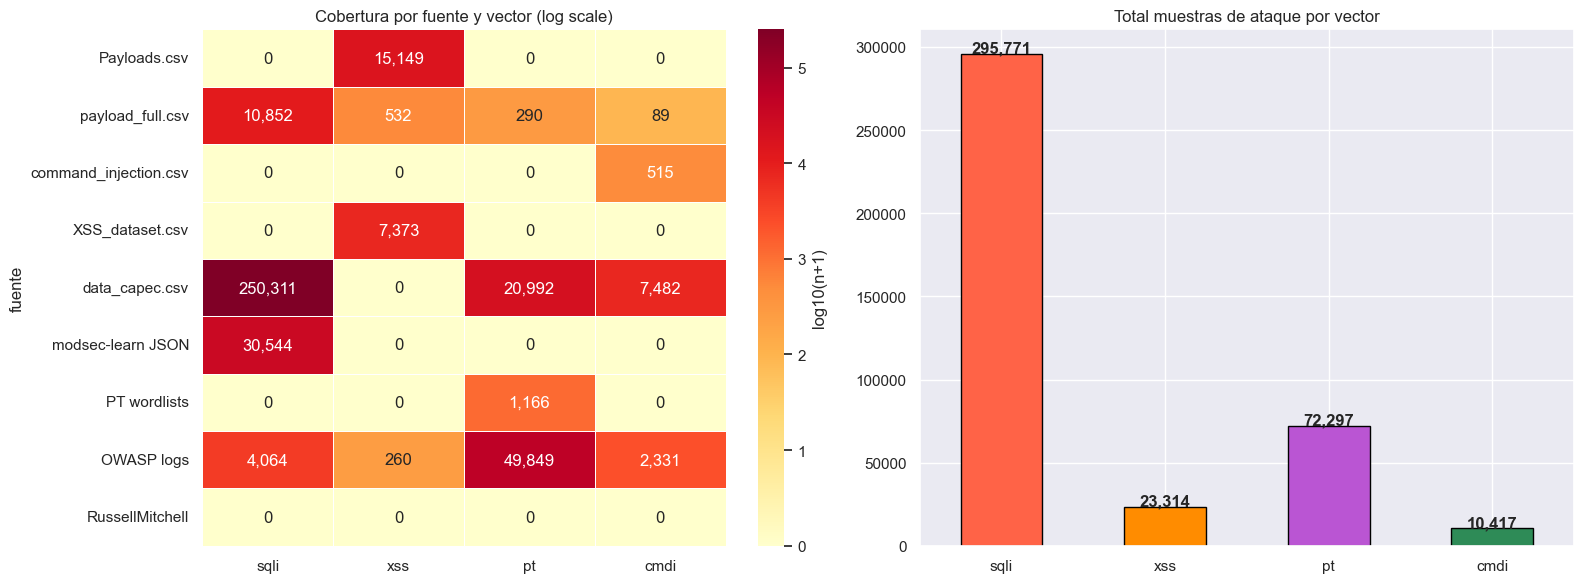

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de coverage
import numpy as np
log_coverage = coverage.apply(lambda x: np.log10(x + 1))
sns.heatmap(log_coverage, annot=coverage.values, fmt=",", cmap="YlOrRd",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "log10(n+1)"})
axes[0].set_title("Cobertura por fuente y vector (log scale)")
axes[0].tick_params(axis="y", rotation=0)

# Totales por vector
totals.plot(kind="bar", ax=axes[1],
            color=["tomato", "darkorange", "mediumorchid", "seagreen"], edgecolor="black")
axes[1].set_title("Total muestras de ataque por vector")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(totals):
    axes[1].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [24]:
# Tabla de compatibilidad de esquemas
schema_table = pd.DataFrame([
    {"fuente":"Payloads.csv",         "schema":"payload texto",       "encoding":"latin-1",  "combinable_directo":"Si (+ extraccion QS)"},
    {"fuente":"payload_full.csv",     "schema":"payload texto",       "encoding":"utf-8",    "combinable_directo":"Si"},
    {"fuente":"command_injection.csv","schema":"payload texto",       "encoding":"latin-1",  "combinable_directo":"Si (+ HTML-decode)"},
    {"fuente":"XSS_dataset.csv",      "schema":"payload texto",       "encoding":"utf-8",    "combinable_directo":"Condicionado (sesgo legitimate)"},
    {"fuente":"data_capec.csv",       "schema":"HTTP request completo","encoding":"utf-8",   "combinable_directo":"No (requiere FE)"},
    {"fuente":"modsec-learn JSON",    "schema":"payload texto",       "encoding":"utf-8",    "combinable_directo":"Si (+ deduplicar)"},
    {"fuente":"PT wordlists (Dp.txt)","schema":"payload texto",       "encoding":"utf-8",    "combinable_directo":"Si (attack-only)"},
    {"fuente":"OWASP logs",           "schema":"HTTP request completo","encoding":"utf-8",   "combinable_directo":"No (requiere parseo)"},
    {"fuente":"RussellMitchell logs", "schema":"Apache CLF",          "encoding":"utf-8",    "combinable_directo":"Solo como legitimate (parseo CLF)"},
]).set_index("fuente")

print(schema_table.to_string())

                                      schema encoding                 combinable_directo
fuente                                                                                  
Payloads.csv                   payload texto  latin-1               Si (+ extraccion QS)
payload_full.csv               payload texto    utf-8                                 Si
command_injection.csv          payload texto  latin-1                 Si (+ HTML-decode)
XSS_dataset.csv                payload texto    utf-8    Condicionado (sesgo legitimate)
data_capec.csv         HTTP request completo    utf-8                   No (requiere FE)
modsec-learn JSON              payload texto    utf-8                  Si (+ deduplicar)
PT wordlists (Dp.txt)          payload texto    utf-8                   Si (attack-only)
OWASP logs             HTTP request completo    utf-8               No (requiere parseo)
RussellMitchell logs              Apache CLF    utf-8  Solo como legitimate (parseo CLF)


# Seccion 13: Resumen y decisiones
    
## Cobertura total por vector
    
- sqli           : 295,771  muestras  (73.6% del total de ataques in-scope)
- path_traversal :  72,297  muestras  (18.0%, dominado por OWASP 930130 sensitive file access)
- xss            :  23,314  muestras  (5.8%)
- cmdi           :  10,417  muestras  (2.6% del total)
- Ratio sqli:cmdi ~ 28:1 -> desbalance critico

## Fuentes de trafico legitimo

- modsec-learn legitimate: 69,101 query strings reales (mejor calidad)
- payload_full norm      : 19,304 direcciones espanolas (sintetico)
- XSS_dataset Label=0    :  6,313 texto Wikipedia (sesgo de dominio)
- command_injection Label=0: 1,591 direcciones espanolas (igual que payload_full)
- RussellMitchell        : ~3,475 peticiones WordPress reales
- Payloads.csv Benign    : 28,068 HTML/JS de paginas web (parcialmente util)

## Problemas criticos para dataset construction

1. Desbalance sqli:cmdi = 28:1
   Estrategia requerida: undersampling sqli + oversample cmdi, o class_weight

2. Heterogeneidad de la clase legitimate:
   Cuatro distribuciones distintas (query strings reales, direcciones espanolas,
   texto Wikipedia, HTML de paginas web). Combinar sin estratificacion genera
   una clase legitimate artificialmente facil de separar por dominio.

3. path_traversal de OWASP dominado por 930130 (sensitive file access), NO traversal clasico:
   49,849 transacciones de acceso a /.git/config, /wp-config.php, /.env
   El dataset resultante tendra mas reconnaissance de archivos sensibles que ../../etc/passwd.
   Decidir si se acepta la definicion amplia de LFI o se filtra por regla.

4. data_capec y OWASP logs no combinables directamente:
   Requieren extraccion de features (request path + query string) antes
   de unificar con los CSVs de payload texto.

5. XSS_dataset legitimate tiene sesgo de longitud:
   Media de Label=0 es 10x mayor que Label=1. Verificar que el modelo
   no aprenda longitud como discriminador principal.

6. RussellMitchell NO aporta muestras de ataque in-scope:
   Util solo como trafico legitimo de WordPress.

7. PT wordlists all-*.txt: 125K lineas de ENUMERACION, no Path Traversal
   Solo Dp.txt (1,166) y Deep-Travelsal.txt (879 templates) son PT reales.

## Estado por fuente: GO / CONDICIONADO / DESCARTAR

| Fuente                      | Decision      | Condicion |
|-----------------------------|---------------|-----------|
| payload_full.csv            | GO            | Renombrado de columnas |
| modsec-learn JSON           | GO            | Deduplicar legitimate |
| command_injection.csv       | GO            | HTML-decode, dedup, cuidado al combinar con payload_full |
| Payloads.csv                | CONDICIONADO  | Extraer QS, confirmar que todo Malicious = xss |
| XSS_dataset.csv             | CONDICIONADO  | Monitorear sesgo de longitud en evaluacion |
| OWASP logs path_traversal   | GO            | Parsear y exportar con nueva clasificacion |
| OWASP logs sqli/xss/cmdi    | GO            | Incluir en mismo parseo |
| data_capec_multilabel.csv   | GO (FE)       | Extraer request_http_request, colapsar labels |
| PT wordlists Dp.txt         | GO            | Attack-only, combinar con clase legitimate |
| PT wordlists Deep-Travelsal | CONDICIONADO  | Sustituir placeholder {FILE} |
| PT wordlists all-*.txt      | DESCARTAR     | Son listas de enumeracion, NO PT payloads |
| RussellMitchell logs        | CONDICIONADO  | Solo como legitimate, parsear CLF |